In [2]:
!pip install tensorflow_datasets

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dataset, info = tfds.load('cats_vs_dogs',with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.57NA2B_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [11]:
class_names = info.features['label'].names

In [17]:
for i,example in enumerate(dataset['train']):
  #example = (image,label)
  image, label = example
  save_dir = './cats_vs_dogs/train/{}'.format(class_names[label])
  os.makedirs(save_dir,exist_ok=True)
  filename = save_dir + "/" + "{}_{}.jpg".format(class_names[label],i)
  tf.keras.preprocessing.image.save_img(filename,image.numpy())

**CNN buildng blocks**

    Input Layers
    Convolutional layer
    Pooling layer
    Dropout layer
    Batch normalisation layer
    Activation layer
    Fully Connected layer
    Fltten layer
    Output layer




In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

In [36]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2,rotation_range=10,
                             width_shift_range=0.1,height_shift_range=0.1,
                             shear_range=0.1,zoom_range=0.10,horizontal_flip=True)

train_generator = datagen.flow_from_directory('/content/cats_vs_dogs/train',
                                              target_size = (150,150),
                                              batch_size=216,
                                              class_mode='binary',
                                              subset='training')

validation_generator = datagen.flow_from_directory('/content/cats_vs_dogs/train',
                                              target_size = (150,150),
                                              batch_size=216,
                                              class_mode='binary',
                                              subset='validation')

Found 18611 images belonging to 2 classes.
Found 4651 images belonging to 2 classes.


In [37]:
model = Sequential()

In [38]:
model = Sequential()

# 1st layer
model.add(Conv2D(32, kernel_size=3,
                 activation='relu',
                 input_shape=(150,150,3)))
model.add(MaxPool2D(2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# 2nd layer
model.add(Conv2D(64, kernel_size=3,
                 activation='relu'))
model.add(MaxPool2D(2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# 3rd layer
model.add(Conv2D(128, kernel_size=3,
                 activation='relu'))
model.add(MaxPool2D(2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Fully connected
model.add(Flatten())

model.add(Dense(512,
                activation='relu'))

model.add(Dropout(0.3))

# Output layer
model.add(Dense(1,
                activation='sigmoid'))

In [39]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,073 (72.61 MB)

 Trainable params: 19,034,625 (72.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [55]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(train_generator,epochs=10, validation_data=validation_generator)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7965 - loss: 0.4401 - val_accuracy: 0.7067 - val_loss: 0.7767
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8169 - loss: 0.4046 - val_accuracy: 0.7579 - val_loss: 0.5863
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8319 - loss: 0.3781 - val_accuracy: 0.8301 - val_loss: 0.3857
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8403 - loss: 0.3586 - val_accuracy: 0.8280 - val_loss: 0.4113
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8503 - loss: 0.3425 - val_accuracy: 0.8424 - val_loss: 0.4203
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8585 - loss: 0.3226 - val_accuracy: 0.8349 - val_loss: 0.3883
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8677 - loss: 0.3014 - val_accuracy: 0.8643 - val_loss: 0.3234
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8771 - loss: 0.2903 - val_accuracy: 0.8357 - v

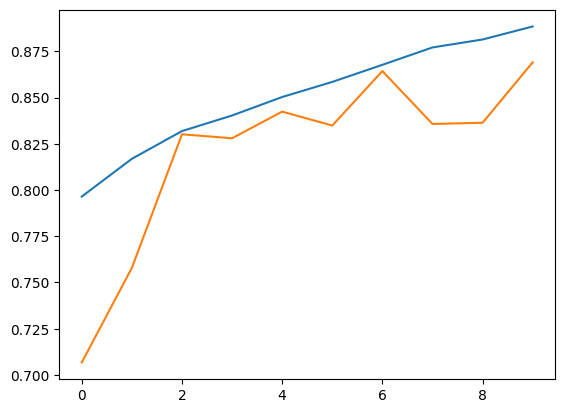

In [56]:
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

In [62]:
#save model
model.save('cats_vs_dogs.h5')

In [63]:
model.load = tf.keras.models.load_model('cats_vs_dogs.h5')

In [72]:
import requests
from PIL import Image

image_url = "https://d2zp5xs5cp8zlg.cloudfront.net/image-83814-340.jpg"

img = Image.open(
    requests.get(image_url, stream=True).raw
).resize((150,150))

image_array = image.img_to_array(img)

img = np.expand_dims(image_array, axis=0)

img = img/255

prediction = model.predict(img)

print("Raw output:", prediction)

pred = 1 if prediction[0][0] > 0.5 else 0

classes = {v:k for k,v in train_generator.class_indices.items()}

print("Predicted class:", classes[pred])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Raw output: [[0.21993889]]
Predicted class: cat
